# Music Support Bot Notebook

## Setup

In [156]:
import operator
import sqlite3
import textwrap
from enum import Enum
from typing import Annotated, Literal

import requests
from IPython.display import Image, display
from langchain_community.utilities.sql_database import SQLDatabase
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI

from langchain_core.messages import SystemMessage, HumanMessage


from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, interrupt
from pydantic import BaseModel, Field
from sqlalchemy import create_engine, text
from sqlalchemy.pool import StaticPool

In [157]:

# Database setup
def get_engine_for_chinook_db():
    """Pull sql file, populate in-memory database, and create engine."""
    url = "https://raw.githubusercontent.com/lerocha/chinook-database/master/ChinookDatabase/DataSources/Chinook_Sqlite.sql"
    response = requests.get(url)
    sql_script = response.text

    connection = sqlite3.connect(":memory:", check_same_thread=False)
    connection.executescript(sql_script)
    return create_engine(
        "sqlite://",
        creator=lambda: connection,
        poolclass=StaticPool,
        connect_args={"check_same_thread": False},
    )


engine = get_engine_for_chinook_db()
db = SQLDatabase(engine)


def fetch_songs_by_genre(genre_name: str) -> list[dict]:
    """Internal helper: query songs by genre, returns list of dicts."""
    with engine.connect() as conn:
        result = conn.execute(
            text("""
                SELECT
                    t.TrackId AS track_id,
                    t.Name AS track_name,
                    g.Name AS genre_name,
                    al.Title AS album_title,
                    ar.Name AS artist_name,
                    t.Composer AS composer,
                    t.Milliseconds AS milliseconds,
                    t.Bytes AS bytes,
                    t.UnitPrice AS unit_price
                FROM Track t
                JOIN Genre g ON t.GenreId = g.GenreId
                LEFT JOIN Album al ON t.AlbumId = al.AlbumId
                LEFT JOIN Artist ar ON al.ArtistId = ar.ArtistId
                WHERE g.Name LIKE :genre
                ORDER BY RANDOM()
                LIMIT 10
            """),
            {"genre": f"%{genre_name}%"},
        )
        return [dict(row._mapping) for row in result]


@tool
def recommend_songs_by_genre(genre: str):
    """Recommend songs by genre."""
    print(f"recommend_songs_by_genre: {genre}")
    return db.run(
        f"""
        SELECT Track.Name as SongName, Genre.Name as GenreName
        FROM Track
        LEFT JOIN Genre ON Track.GenreId = Genre.GenreId
        WHERE Genre.Name LIKE '%{genre}%';
        """,
        include_columns=True,
    )


@tool
def get_albums_by_artist(artist: str):
    """Get albums by an artist."""
    print(f"get_albums_by_artist: {artist}")
    return db.run(
        f"""
        SELECT * FROM public.artist
        ORDER BY artist_id ASC 
        """,
        include_columns=True,
    )


@tool
def get_tracks_by_artist(artist: str):
    """Get songs by an artist (or similar artists)."""
    print(f"get_tracks_by_artist: {artist}")
    return db.run(
        f"""
        SELECT Track.Name as SongName, Artist.Name as ArtistName
        FROM Album
        LEFT JOIN Artist ON Album.ArtistId = Artist.ArtistId
        LEFT JOIN Track ON Track.AlbumId = Album.AlbumId
        WHERE Artist.Name LIKE '%{artist}%';
        """,
        include_columns=True,
    )


@tool
def check_for_songs(song_title: str):
    """Check if a song exists by its name."""
    print(f"check_for_songs: {song_title}")
    return db.run(
        f"""
        SELECT * FROM Track WHERE Name LIKE '%{song_title}%';
        """,
        include_columns=True,
    )


@tool
def check_for_songs_by_genre(genre_name: str):
    """Check for songs that belong to a genre by genre name."""
    print(f"check_for_songs_by_genre: {genre_name}")
    return fetch_songs_by_genre(genre_name)



In [ ]:
# Music related models and constants

genre_names = [
    "Rock",
    "Jazz",
    "Metal",
    "Alternative & Punk",
    "Rock And Roll",
    "Blues",
    "Latin",
    "Reggae",
    "Pop",
    "Soundtrack",
    "Bossa Nova",
    "Easy Listening",
    "Heavy Metal",
    "R&B/Soul",
    "Electronica/Dance",
    "World",
    "Hip Hop/Rap",
    "Science Fiction",
    "TV Shows",
    "Sci Fi & Fantasy",
    "Drama",
    "Comedy",
    "Alternative",
    "Classical",
    "Opera",
]


class GenreExtraction(BaseModel):
    genres: list[str] | None = Field(
        default=None,
        description="List of music genres identified from the message",
    )


class SongDocument(BaseModel):
    track_id: int
    track_name: str
    genre_name: str | None = None
    album_title: str | None = None
    artist_name: str | None = None
    composer: str | None = None
    milliseconds: int | None = None
    bytes: int | None = None
    unit_price: float | None = None


class MusicQuery(BaseModel):
    artist: list[str] | None = Field(
        default=None, description="The names of artists mentioned in the message"
    )
    album: list[str] | None = Field(
        default=None, description="The names of albums mentioned in the message"
    )
    song: list[str] | None = Field(
        default=None, description="The names of songs mentioned in the message"
    )
    genre: list[str] | None = Field(
        default=None, description="The genres of music mentioned in the message"
    )

In [ ]:
# TODO: customer support models and constants

In [ ]:
# General models and constants

class MessageClassification(BaseModel):
    intent: Literal["parse_music_query", "customer_support", "other"]


class MessageAgentState(BaseModel):
    # Raw message data
    message_content: str
    message_id: int
    sender_number: str

    # Classification result
    message_classification: MessageClassification | None = None

    # Music query
    music_query: MusicQuery | None = None
    song_recommendations: Annotated[list[SongDocument], operator.add] = Field(
        default_factory=list
    )

    # Agent message
    agent_message: str | None = None

## Define Nodes

In [159]:
# Setup LLM
reasoning = {
    "effort": "low",  # 'low', 'medium', or 'high'
    "summary": None,  # 'detailed', 'auto', or None
}

llm = ChatOpenAI(model="gpt-5-nano", reasoning=reasoning)

In [160]:
# -----------------------------------------------------------------------------
# Classify intent
# -----------------------------------------------------------------------------


def classify_intent(state: MessageAgentState) -> MessageAgentState:
    """Use LLM to classify email intent and urgency, then route accordingly"""

    # Create structured LLM that returns MessageClassification
    structured_llm = llm.with_structured_output(MessageClassification)

    classification_prompt = textwrap.dedent(
        f"""
    Analyze this customer message and classify it:

    Message: {state.message_content}

    Provide a classification:
    - intent: either "parse_music_query" or "customer_support" or "other"

    parse_music_query: user is asking about music, artists, albums, or playlists
    customer_support: user is asking for help with their account, billing, or technical issues
    other: if the message doesn't fit either category or is too vague to classify
    """
    )

    # Get structured output from LLM
    message_classification = structured_llm.invoke(classification_prompt)
    state.message_classification = message_classification

    print("Message classification:", state.message_classification)

    return state


def route_after_classification(
    state: MessageAgentState,
) -> Literal["customer_support_query", "parse_music_query", "__end__"]:
    if (
        state.message_classification
        and state.message_classification.intent == "customer_support"
    ):
        return "customer_support_query"
    if (
        state.message_classification
        and state.message_classification.intent == "parse_music_query"
    ):
        return "parse_music_query"
    return END


# -----------------------------------------------------------------------------
# Music recommendation query parsing
# -----------------------------------------------------------------------------


def parse_music_query(state: MessageAgentState) -> dict:
    structured_llm = llm.with_structured_output(MusicQuery)

    prompt = textwrap.dedent(
        f"""
        You are extracting structured music query information from a user message.

        Your job is to extract only the music entities the user wants recommendations based on.

        Message:
        {state.message_content}

        Extract the following fields:
        - artist: the artist the user wants music based on, or None
        - album: the album the user wants music based on, or None
        - song: the song the user wants music based on, or None

        Important rules:
        - Only extract music entities that the user is positively asking for or using as the reference point.
        - Ignore music entities the user says they do NOT want, do NOT like, want to avoid, or do not want included.
        - Ignore negative examples, exclusions, and contrastive phrases.

        Examples:
        - "Find me songs like Prince" -> artist="Prince", album=None, song=None
        - "Recommend music like Thriller" -> artist=None, album="Thriller", song=None
        - "Give me songs like Yellow" -> artist=None, album=None, song="Yellow"
        - "Find me music like Prince but not Michael Jackson" -> artist="Prince", album=None, song=None
        - "I want songs like Purple Rain, not stuff by Aerosmith" -> artist=None, album=None, song="Purple Rain"
        - "Recommend albums like Rumours, but no U2" -> artist=None, album="Rumours", song=None
        - "No jazz, give me music like Daft Punk" -> artist="Daft Punk", album=None, song=None

        If multiple positive anchors are present, extract the most relevant one the user is asking music based on.
        If no clear positive artist, album, or song is present, return None for all fields.

        Return only the structured output.
        """
    )

    music_query = structured_llm.invoke(prompt)
    print("Parsed music query:", music_query)
    return {"music_query": music_query}


def get_song_recommendations(state: MessageAgentState) -> dict:
    structured_llm = llm.with_structured_output(GenreExtraction)
    prompt = textwrap.dedent(
        f"""
    Extract music genres from this message. Only use genres from this list:
    {", ".join(genre_names)}

    Message: {state.message_content}

    If no genre is mentioned or can be inferred from the artists, songs, or albums mentioned, return None.
    Return each genre only once — no duplicates.
    """
    )
    result = structured_llm.invoke(prompt)

    # Deduplicate while preserving order
    genres = list(dict.fromkeys(result.genres)) if result.genres else None
    print("Identified genres:", genres)

    updated_query = (
        state.music_query.model_copy(update={"genre": genres})
        if state.music_query
        else MusicQuery(genre=genres)
    )

    # Search for songs by genre
    search_results = []
    if genres:
        for genre in genres:
            songs = fetch_songs_by_genre(genre)
            print(f"Songs found for {genre}:", songs)
            for song in songs:
                search_results.append(SongDocument(**song))

    return {"music_query": updated_query, "song_recommendations": search_results}


def generate_song_recommendation_message(state: MessageAgentState) -> MessageAgentState:
    """Format song recommendations into a user-friendly message"""
    formatted_recommendations = []
    for result in state.song_recommendations:
        formatted_recommendations.append(
            f"{result.track_name} by {result.artist_name} (Genre: {result.genre_name}, Album: {result.album_title})"
        )

    if formatted_recommendations:
        original_message = state.message_content
        recommendations_text = "\n".join(formatted_recommendations)

        agent_message = llm.invoke(
            [
                SystemMessage(
                    content="""
        You are a friendly music recommendation assistant.

        Your job is to write a natural, engaging response to the user based on the user's original message and the recommended songs.
        If there are multiple genres, please group songs by the genres and mention the genres in your response.
        If there are multiple genres, limit each genre to 5 songs.

        Instructions:
        - Write a concise, warm, user-facing response
        - Acknowledge the user's request naturally
        - Present the recommendations in an easy-to-read way
        - Keep the recommendations grounded only in the provided songs
        - Do not invent songs, artists, albums, or genres
        - Do not mention internal system details, tools, databases, or classification
        - Use bullet points for the songs
        - End with a light follow-up sentence inviting the user to ask for more
        - Do not include extra analysis
        """
                ),
                HumanMessage(
                    content=f"""
        User's original message:
        {original_message}

        Recommended songs:
        {recommendations_text}
        """
                ),
            ]
        )

        if isinstance(agent_message.content, str):
            state.agent_message = agent_message.content
        else:
            text_blocks = []
            for _, block in enumerate(agent_message.content):
                if isinstance(block, dict) and block.get("type") == "text":
                    text = block.get("text", "")
                    text_blocks.append(text)
            state.agent_message = "\n".join(text_blocks).strip()

    return state


# -----------------------------------------------------------------------------
# Customer support query
# -----------------------------------------------------------------------------


def customer_support_query(state: MessageAgentState) -> MessageAgentState:
    """Handle customer support queries based on classified intent and topic"""
    print("Handling customer support query for:", state.message_content)
    return state

## Build the graph

In [161]:
# Memory
memory = InMemorySaver()


# Build graph
builder = StateGraph(MessageAgentState)


# Add nodes
builder.add_node("classify_intent", classify_intent)
builder.add_node("customer_support_query", customer_support_query)
builder.add_node("parse_music_query", parse_music_query)
builder.add_node("get_song_recommendations", get_song_recommendations)
builder.add_node("generate_song_recommendation_message", generate_song_recommendation_message)


# Add edges
builder.add_edge(START, "classify_intent")

builder.add_conditional_edges(
    "classify_intent",
    route_after_classification,
    [
        "customer_support_query",
        "parse_music_query",
        END,
    ],
)

builder.add_edge("parse_music_query", "get_song_recommendations")
builder.add_edge("get_song_recommendations", "generate_song_recommendation_message")
builder.add_edge("generate_song_recommendation_message", END)
builder.add_edge("customer_support_query", END)

# Build graph
graph = builder.compile(checkpointer=memory)


message_id = 0

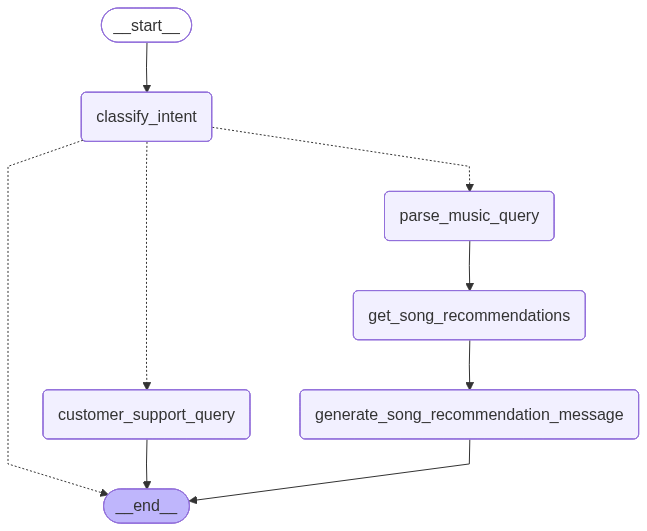

In [162]:
display(Image(graph.get_graph().draw_mermaid_png()))

## Test

In [ ]:
# Simulate incoming message
message_id += 1

initial_message = MessageAgentState(
    message_content="Find me music like AC/DC but not like Prince",
    message_id=message_id,
    sender_number="555-123-1234",
)

config = {"configurable": {"thread_id": str(message_id)}}
result = graph.invoke(initial_message, config=config)

In [164]:
# Simulate incoming message
message_id += 1

initial_message = MessageAgentState(
    message_content="Songs like Yellow, but not Coldplay deep cuts",
    message_id=message_id,
    sender_number="555-123-1234",
)

config = {"configurable": {"thread_id": str(message_id)}}
result = graph.invoke(initial_message, config=config)

Message classification: intent='parse_music_query'
Parsed music query: artist=None album=None song=None genre=None
Identified genres: ['Rock', 'Alternative & Punk', 'Pop', 'Rock And Roll']
Songs found for Rock: [{'track_id': 796, 'track_name': 'Somebody Stole My Guitar', 'genre_name': 'Rock', 'album_title': 'Purpendicular', 'artist_name': 'Deep Purple', 'composer': 'Ian Gillan, Roger Glover, Jon Lord, Steve Morse, Ian Paice', 'milliseconds': 249443, 'bytes': 8180421, 'unit_price': 0.99}, {'track_id': 349, 'track_name': 'You Shook Me(2)', 'genre_name': 'Rock', 'album_title': 'BBC Sessions [Disc 1] [Live]', 'artist_name': 'Led Zeppelin', 'composer': 'J B Lenoir/Willie Dixon', 'milliseconds': 619467, 'bytes': 20138673, 'unit_price': 0.99}, {'track_id': 1615, 'track_name': 'Four Sticks', 'genre_name': 'Rock', 'album_title': 'IV', 'artist_name': 'Led Zeppelin', 'composer': 'Jimmy Page, Robert Plant', 'milliseconds': 284447, 'bytes': 9481301, 'unit_price': 0.99}, {'track_id': 28, 'track_name